In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
import numpy as np
import matplotlib.pyplot as plt

In [4]:

# 1. GENERATE DUMMY DATA (Like your university project data)
# 1000 samples, 20 features
X = np.random.random((1000, 20))
y = np.random.randint(2, size=(1000, 1)) # Binary classification (0 or 1)


In [8]:


# 2. DEFINE THE MODEL ARCHITECTURE
model = models.Sequential([
    # Input Layer + Hidden Layer 1
    # We use 'he_normal' initialization because we are using 'relu'
    layers.Dense(64, input_shape=(20,), kernel_initializer='he_normal'),
    
    # BATCH NORMALIZATION: Keeps the signal steady
    layers.BatchNormalization(),
    layers.Activation('relu'),
    
    # DROPOUT: Prevents overfitting by shutting off 20% of neurons
    layers.Dropout(0.32),
    
    # Hidden Layer 2
    layers.Dense(32, kernel_initializer='he_normal'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    
    # Output Layer (Sigmoid for binary classification)
    layers.Dense(1, activation='sigmoid')
])


Starting Training...
Epoch 1/20


25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.4837 - loss: 0.7829 - val_accuracy: 0.5300 - val_loss: 0.7251
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5213 - loss: 0.7353 - val_accuracy: 0.5250 - val_loss: 0.7178
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5125 - loss: 0.7185 - val_accuracy: 0.5300 - val_loss: 0.7123
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5525 - loss: 0.7025 - val_accuracy: 0.5250 - val_loss: 0.7119
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5387 - loss: 0.6902 - val_accuracy: 0.5150 - val_loss: 0.7092
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5763 - loss: 0.6840 - val_accuracy: 0.5000 - val_loss: 0.7070
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5650 - loss: 0.6844 - val_accuracy: 0.4950 - val_loss: 0.7048
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5663 - loss: 0.6864 - val_accuracy: 0.5050 - val_loss: 0.7042
Ep

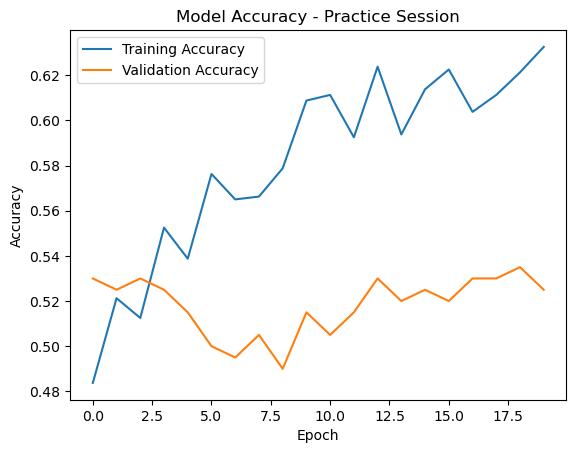

In [ ]:

# 3. SELECT YOUR OPTIMIZER (Practice by switching these!)
# Option A: Standard SGD
# opt = optimizers.SGD(learning_rate=0.01)

# Option B: SGD with Momentum (The "Heavy Ball")
# opt = optimizers.SGD(learning_rate=0.01, momentum=0.9)

# Option C: Adam (The most common/Adaptive)
opt = optimizers.Adam(learning_rate=0.001)

# 4. COMPILE THE MODEL
model.compile(optimizer=opt, 
              loss='binary_crossentropy', 
              metrics=['accuracy']
              
              )

# 5. TRAIN THE MODEL (Using Batch Size and Epochs)
print("Starting Training...")
history = model.fit(X, y, 
                    epochs=20, 
                    batch_size=32, 
                    validation_split=0.2, # Uses 20% of data for testing
                    verbose=1)

# 6. VISUALIZE THE RESULTS
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy - Practice Session')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [10]:
# 7. PRINT FINAL ACCURACY
# Method 1: Get the very last value from the training history
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]

print(f"\nFinal Training Accuracy: {final_train_acc * 100:.2f}%")
print(f"Final Validation Accuracy: {final_val_acc * 100:.2f}%")

# Method 2: Evaluate using the model.evaluate function (more formal)
loss, accuracy = model.evaluate(X, y, verbose=0)
print(f"Overall Model Accuracy on full dataset: {accuracy * 100:.2f}%")


Final Training Accuracy: 63.25%
Final Validation Accuracy: 52.50%
Overall Model Accuracy on full dataset: 67.10%
